(adstock_functions_guide)=
# Guide to Adstock Transformations in PyMC-Marketing

This notebook provides a comprehensive overview of the different adstock transformations available in PyMC-Marketing. Adstock effects model the delayed and lagged impact of marketing spend on consumer behavior.

## What is Adstock?

**Adstock** (also called the **carryover effect** or **lagged effect**) is a fundamental concept in marketing that models how advertising impact doesn't happen instantaneously. Instead, it **builds up over time and gradually decays**.

### The Core Idea

When you run an advertising campaign, the effects don't just appear in the same week and then disappear completely. There are three major behaviors that we need to keep in mind:

- **Memory effect**: Consumers remember your ad after seeing it (think of that jingle from a TV commercial you saw years ago)
- **Delayed response**: It may take time for someone to act on your advertisement
- **Gradual decay**: The impact slowly fades over subsequent time periods

### Why Adstock Matters for MMMs

Understanding adstock effects is crucial for:

1. **Budget Planning**: If a channel has long-lasting effects, you might advertise less frequently but still maintain impact
2. **Attribution**: Correctly assigning sales to the marketing that caused them, even if there's a time lag
3. **ROAS Calculation**: Ensuring you capture the full return, not just immediate effects
4. **Channel Comparison**: Different channels have different decay patterns (e.g., TV ads vs. digital banner ads)

### Mathematical Representation

The simplest form is **Geometric Adstock**, where the transformed value at time $t$ is:

$$x_t^{\textrm{transf}} = x_t + \alpha x_{t-1}^{\textrm{transf}}$$

Where:
- $x_t$ is the raw advertising spend at time $t$
- $\alpha \in [0, 1]$ is the **retention rate** (how much of the effect carries over)
- Higher $\alpha$ means slower decay (longer-lasting effects)

This creates an exponential decay pattern where the effect of advertising in week 0 continues into weeks 1, 2, 3, etc., diminishing by factor $\alpha$ each period.

### Types of Adstock in PyMC-Marketing

The library offers several adstock transformations to model different decay patterns:

1. **Geometric Adstock**: Simple exponential decay (most common, good default choice)
2. **Delayed Adstock**: Adds a delay parameter, peak effect happens after $\theta$ periods
3. **Weibull PDF/CDF Adstock**: More flexible decay curves that can model peak-then-decay patterns
4. **Binomial Adstock**: Alternative flexible decay specification

### Real-World Intuition

Different advertising channels exhibit different decay patterns:

- **Digital display ads**: Might have $\alpha \approx 0.2$ (fast decay, effects last 1-2 weeks)
- **TV brand campaigns**: Might have $\alpha \approx 0.7$ (slow decay, effects last months)
- **Billboard advertising**: Might have delayed peak if it takes time for brand awareness to convert to action

The adstock transformation ensures that when you model sales as a function of marketing spend, you're capturing the full temporal dynamics of how advertising actually influences consumer behavior.

---

## The Layout
We'll explore:
- **Geometric Adstock**: Simple exponential decay
- **Delayed Adstock**: Geometric with a delay parameter
- **Binomial Adstock**: Flexible decay curve
- **Weibull PDF Adstock**: Peak effect before decay
- **Weibull CDF Adstock**: S-shaped cumulative effect

For each, we'll:
1. Explain when to use it
2. Visualize the decay curve
3. Apply it to real marketing data
4. Show the transformed spend over time

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor.xtensor as ptx
import seaborn as sns

from pymc_marketing.mmm import (
    BinomialAdstock,
    DelayedAdstock,
    GeometricAdstock,
    WeibullCDFAdstock,
    WeibullPDFAdstock,
)
from pymc_marketing.mmm.transformers import WeibullType, weibull_adstock

# Set plotting style with colorblind-friendly palette
sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (14, 6)
%config InlineBackend.figure_format = "retina"

# Define colorblind-friendly colors for consistent use
CB_COLORS = sns.color_palette("colorblind")
COLOR_CH1 = CB_COLORS[9]
COLOR_CH2 = CB_COLORS[2]

# Load the example dataset
url = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mmm_example.csv"
data = pd.read_csv(url, parse_dates=["date_week"])
print(f"Dataset shape: {data.shape}")
data.head(10)

/opt/anaconda3/envs/pymc-dev/lib/python3.12/site-packages/pytensor/xtensor/__init__.py:14: UserWarning: xtensor module is experimental and full of bugs
  warnings.warn("xtensor module is experimental and full of bugs")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Dataset shape: (179, 8)


,date_week,y,x1,x2,event_1,event_2,dayofyear,t
0,2018-04-02,3984.662237,0.318580,0.000000,0.0,0.0,92,0
1,2018-04-09,3762.871794,0.112388,0.000000,0.0,0.0,99,1
2,2018-04-16,4466.967388,0.292400,0.000000,0.0,0.0,106,2
3,2018-04-23,3864.219373,0.071399,0.000000,0.0,0.0,113,3
4,2018-04-30,4441.625278,0.386745,0.000000,0.0,0.0,120,4
5,2018-05-07,3677.396550,0.047171,0.000000,0.0,0.0,127,5
6,2018-05-14,5067.546337,0.424249,0.000000,0.0,0.0,134,6
7,2018-05-21,6079.099042,0.333920,0.879782,0.0,0.0,141,7
8,2018-05-28,4954.205369,0.253070,0.000000,0.0,0.0,148,8
9,2018-06-04,5865.676576,0.938054,0.000000,0.0,0.0,155,9


## Understanding the Data

Let's visualize our marketing spend channels (`x1` and `x2`) over time:

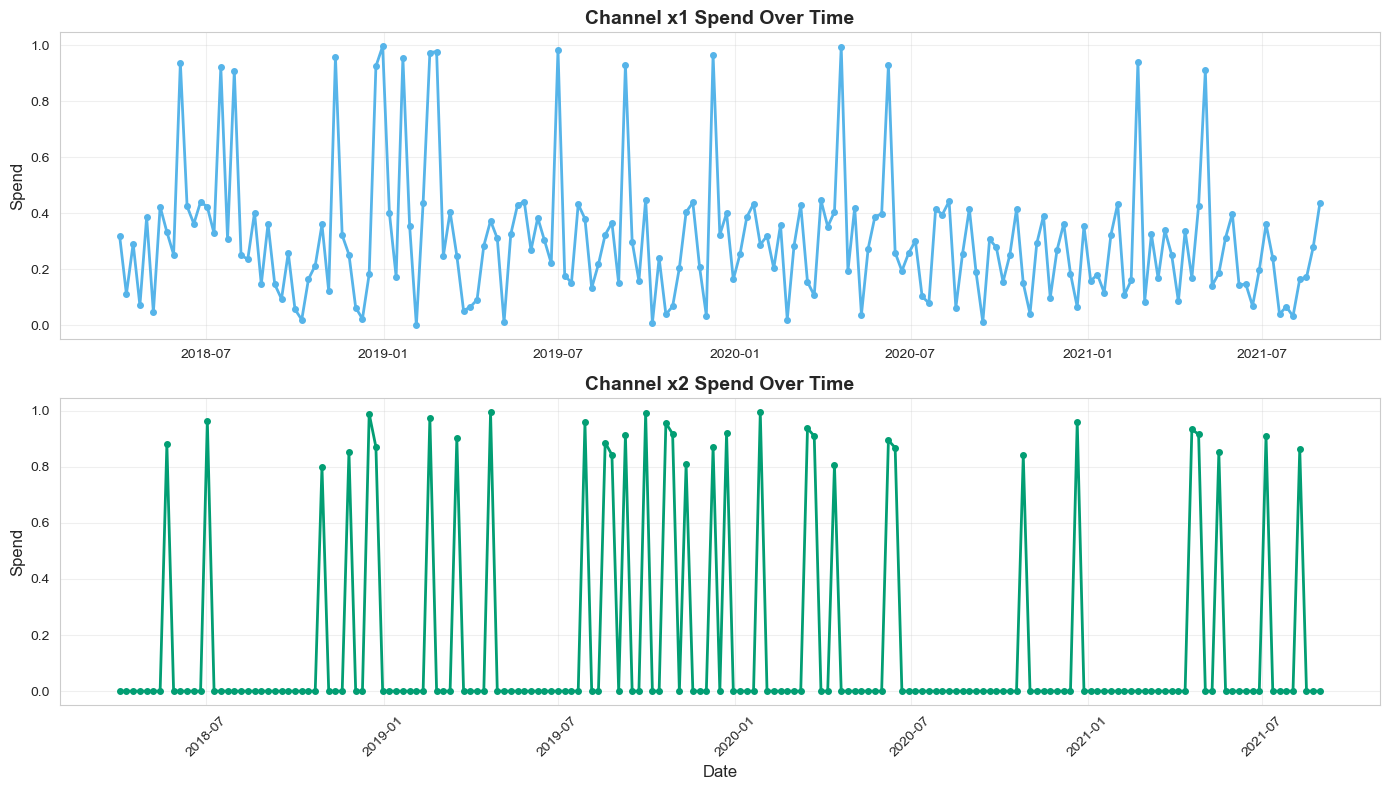

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot channel x1
axes[0].plot(
    data["date_week"],
    data["x1"],
    marker="o",
    linewidth=2,
    markersize=4,
    color=COLOR_CH1,
)
axes[0].set_title("Channel x1 Spend Over Time", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Spend", fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot channel x2
axes[1].plot(
    data["date_week"],
    data["x2"],
    marker="o",
    linewidth=2,
    markersize=4,
    color=COLOR_CH2,
)
axes[1].set_title("Channel x2 Spend Over Time", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Spend", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

---

## 1. Geometric Adstock

### Overview
Geometric adstock is the **simplest and most commonly used** adstock transformation. It models a **constant exponential decay** where the effect diminishes by a fixed proportion each time period.

### Mathematical Form
$$x_t^{\textrm{transf}} = x_t + \alpha x_{t-1}^{\textrm{transf}}$$

Where:
- $x_t$ is the raw advertising spend at time $t$
- $\alpha \in [0, 1]$ is the **retention rate** (how much of the effect carries over)
- Higher $\alpha$ means slower decay (longer-lasting effects)

### When to Use
- **Default choice** for most marketing mix modeling applications
- When you expect a **simple, consistent decay** in advertising effect
- **Digital advertising** (display ads, search ads) where effects typically fade uniformly
- When you have **limited data** or want model simplicity
- **Awareness campaigns** where impact gradually declines

### Parameters
- `alpha`: Retention rate (0-1). Higher values = slower decay
- `l_max`: Maximum lag periods to consider

### Generate Geometric Adstock Instance

Here we create a Geometric Adstock instance to help explore different behaviors.

We instantiate the `GeometricAdstock` transformer with two key parameters:
- `l_max=12`: Maximum lag to consider (12 weeks). This defines how far back in time
  the adstock effect extends. For weekly data, 12 weeks (~3 months) is common.
- `normalize=True`: Ensures the adstock weights sum to 1, making the transformation
   interpretable as a weighted average of past spend values.

Before fitting a model, it's useful to visualize what the adstock transformation
looks like under different parameter values:
- `sample_prior()`: Generates random parameter values (alpha) from the prior distribution
- `sample_curve()`: Uses those parameters to create the actual decay curve


In [ ]:
# This instance will be used to transform raw marketing spend data into adstocked
# spend that accounts for the carryover effects over time.
geometric = GeometricAdstock(l_max=12, normalize=True)

# Sample the prior and curve
# This helps us understand the range of decay patterns our model considers plausible
# BEFORE we see any data. It's a sanity check that our priors make sense.
rng = np.random.default_rng(42)
prior = geometric.sample_prior(random_seed=rng)
curve = geometric.sample_curve(prior)

print("Geometric Adstock Configuration:")
print(geometric)

Sampling: [adstock_alpha]
Sampling: []


Output()

Geometric Adstock Configuration:
GeometricAdstock(prefix='adstock', l_max=12, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3)})


If you noticed when running the above cell, we print out the `geometric` object. This enables us to look into how we configured our Adstock effects. Let's dive into the priors!

- **`priors`**: A dictionary specifying the prior distribution for the `alpha` parameter (retention rate). For example, `Prior("Beta", alpha=1, beta=3)` creates a Beta(1,3) prior that favors lower alpha values (faster decay), which is often reasonable for marketing effects.

The alpha parameter ($\alpha \in [0, 1]$) controls the **retention rate**:
- $\alpha = 0$: No carryover effect (only immediate impact)
- $\alpha = 0.5$: Moderate decay (effect halves each period)
- $\alpha = 0.9$: Very slow decay (long-lasting memory effect)

```{tip}
We also allow you to choose when to transform the spend. Whether it's before or after the saturation transformation. See below! 
- **`mode`**: Determines when the adstock transformation is applied in the model pipeline:
  - `'After'`: Apply adstock after saturation transformations (most common)
  - `'Before'`: Apply adstock before saturation transformations
```

### Decay Curves for Different Alpha Values

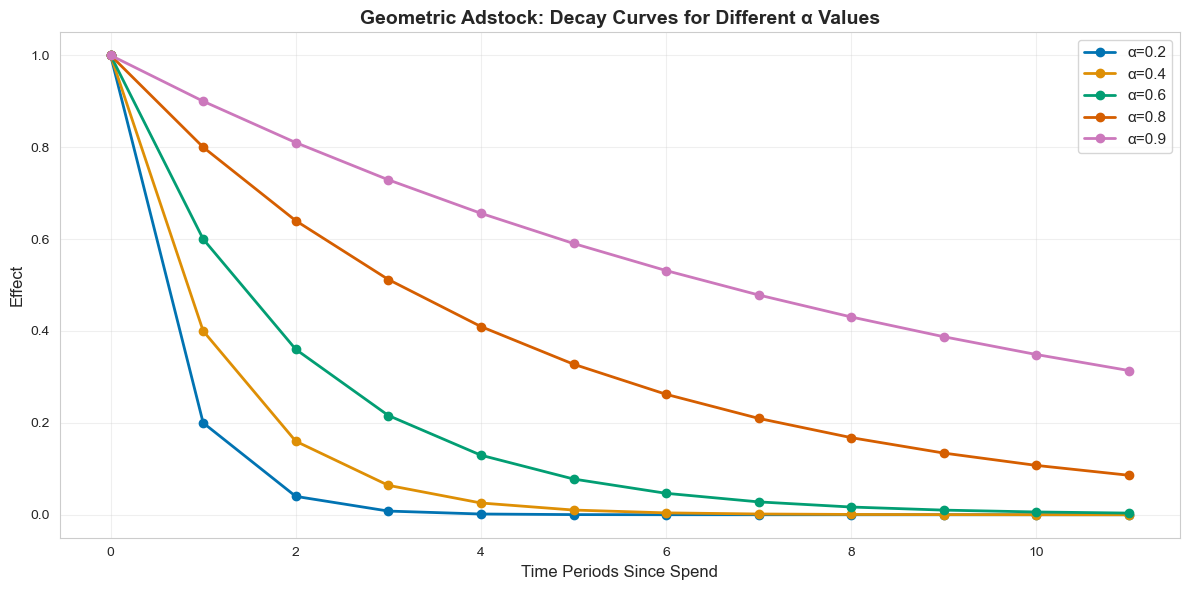


Interpretation:
- Higher α (e.g., 0.9) = slower decay, longer-lasting effect
- Lower α (e.g., 0.2) = faster decay, short-lived effect


In [21]:
from pymc_marketing.mmm.transformers import geometric_adstock

fig, ax = plt.subplots(figsize=(12, 6))

# Test different alpha values
alphas = [0.2, 0.4, 0.6, 0.8, 0.9]
l_max = 12

# Create impulse (single unit of spend at time 0)
impulse = np.zeros(l_max)
impulse[0] = 1.0

for alpha in alphas:
    result = geometric_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        alpha=alpha,
        l_max=l_max,
        normalize=False,
        dim="time",
    )
    ax.plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"α={alpha}")

ax.set_xlabel("Time Periods Since Spend", fontsize=12)
ax.set_ylabel("Effect", fontsize=12)
ax.set_title(
    "Geometric Adstock: Decay Curves for Different α Values",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Higher α (e.g., 0.9) = slower decay, longer-lasting effect")
print("- Lower α (e.g., 0.2) = faster decay, short-lived effect")

### Apply Geometric Adstock to Channel Data

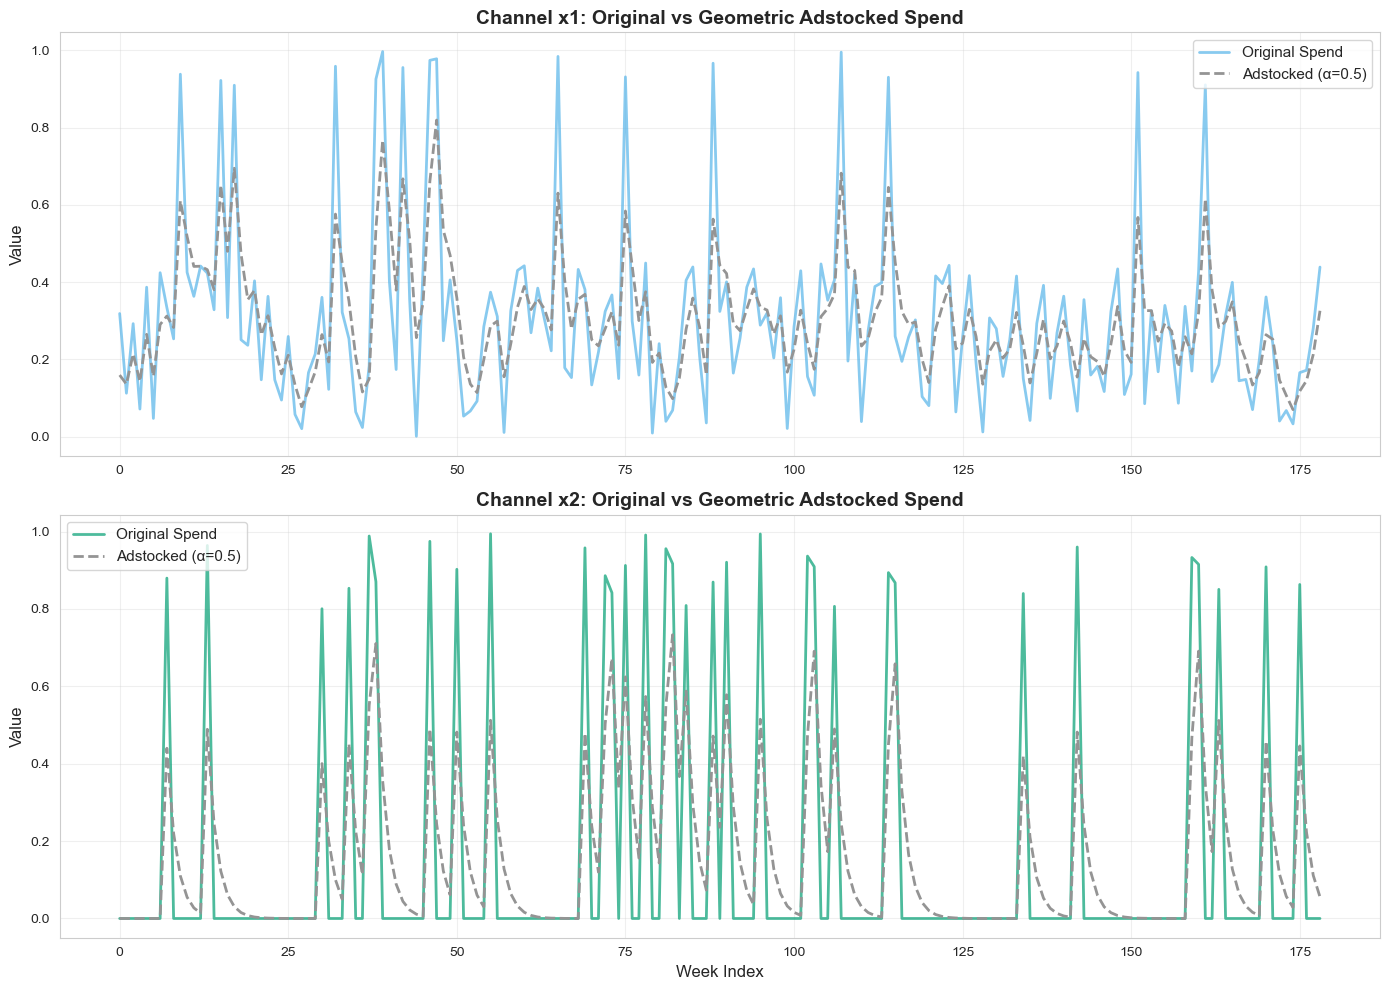

In [17]:
# Apply geometric adstock with alpha=0.5 (moderate decay)
alpha = 0.5
x1_adstocked_geo = geometric_adstock(
    ptx.as_xtensor(data["x1"].values, dims=("time",)),
    alpha=alpha,
    l_max=12,
    normalize=True,
    dim="time",
).eval()
x2_adstocked_geo = geometric_adstock(
    ptx.as_xtensor(data["x2"].values, dims=("time",)),
    alpha=alpha,
    l_max=12,
    normalize=True,
    dim="time",
).eval()

# Visualize original vs adstocked spend
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Channel x1
ax1 = axes[0]
ax1.plot(
    data.index,
    data["x1"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH1,
)
ax1.plot(
    data.index,
    x1_adstocked_geo,
    label=f"Adstocked (α={alpha})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax1.set_title(
    "Channel x1: Original vs Geometric Adstocked Spend", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Channel x2
ax2 = axes[1]
ax2.plot(
    data.index,
    data["x2"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH2,
)
ax2.plot(
    data.index,
    x2_adstocked_geo,
    label=f"Adstocked (α={alpha})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax2.set_title(
    "Channel x2: Original vs Geometric Adstocked Spend", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Week Index", fontsize=12)
ax2.set_ylabel("Value", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

**Key Observations:**
- The adstocked spend is **smoother** than the original, showing carryover effects
- Peaks in spend create **lingering effects** in subsequent periods
- The transformation captures how today's advertising continues to influence tomorrow's sales

---

## 2. Delayed Adstock

### Overview
Delayed adstock extends geometric adstock by adding a **delay parameter** ($\theta$) that shifts when the peak effect occurs.

### Mathematical Form

Delayed geometric adstock builds on geometric adstock by adding in a delay $\theta$ before the maximum adstock is observed (this happens at week 0 for the plain geometric decay).

It also adds a maximum duration for the carryover/adstock $L_{max}$, such that adstock after this point is 0.

The delayed geometric adstock function takes the following form:

$$x_t^{\textrm{transf}} = \sum_{i=0}^{L_{\max}-1} \left( \alpha^{|i-\theta|} \cdot x_{t-i} \right)$$

Where:
- $x_t^{\textrm{transf}}$ refers to the transformed value at time $t$ after applying the delayed adstock transformation
- $\alpha$ is the retention rate of the ad effect
- $\theta$ represents the delay before the peak effect occurs
- $L_{max}$ is the maximum duration of the carryover effect

### When to Use
- **Broadcast media** (TV, radio) where impact doesn't happen immediately
- **Out-of-home advertising** (billboards) with gradual awareness build-up
- **Awareness campaigns** where recognition takes time to develop
- When there's a **lag between exposure and action** (e.g., B2B marketing)
- **Brand campaigns** rather than performance marketing

### Parameters
- `alpha`: Retention rate (0-1)
- `theta`: Delay parameter (higher = more delay)
- `l_max`: Maximum lag periods

In [22]:
# Create Delayed Adstock instance
delayed = DelayedAdstock(l_max=12, normalize=True)

print("Delayed Adstock Configuration:")
print(delayed)

Delayed Adstock Configuration:
DelayedAdstock(prefix='adstock', l_max=12, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3), 'theta': Prior("HalfNormal", sigma=1)})


### Decay Curves for Different Delay (θ) Values


Interpretation:
- θ controls when peak effect occurs (higher θ = later peak)
- α controls decay after the peak (higher α = slower decay)


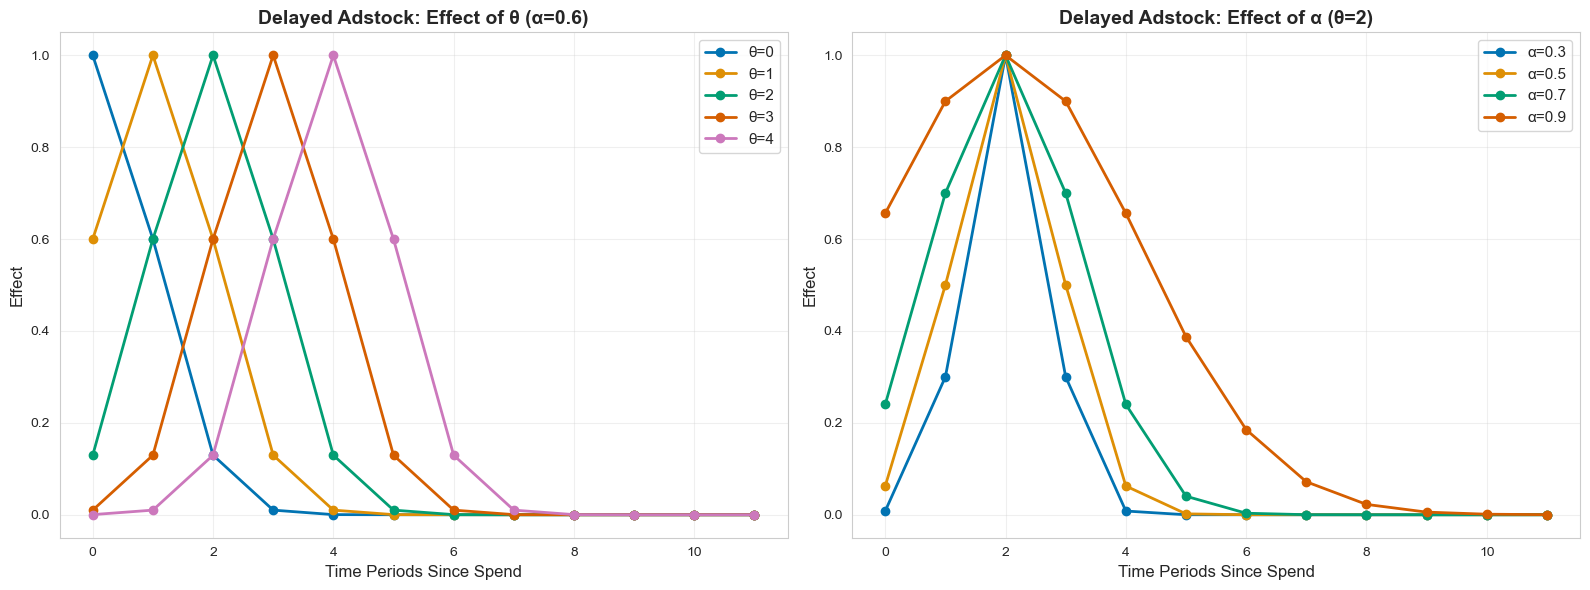

In [26]:
from pymc_marketing.mmm.transformers import delayed_adstock

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test different theta values with fixed alpha
alpha = 0.6
thetas = [0, 1, 2, 3, 4]
l_max = 12

impulse = np.zeros(l_max)
impulse[0] = 1.0

# Left plot: varying theta
for theta in thetas:
    result = delayed_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        alpha=alpha,
        theta=theta,
        l_max=l_max,
        normalize=False,
        dim="time",
    )
    axes[0].plot(
        range(l_max), result.eval(), marker="o", linewidth=2, label=f"θ={theta}"
    )

axes[0].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[0].set_ylabel("Effect", fontsize=12)
axes[0].set_title(
    f"Delayed Adstock: Effect of θ (α={alpha})", fontsize=14, fontweight="bold"
)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right plot: varying alpha with fixed theta
theta = 2
alphas = [0.3, 0.5, 0.7, 0.9]

for alpha in alphas:
    result = delayed_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        alpha=alpha,
        theta=theta,
        l_max=l_max,
        normalize=False,
        dim="time",
    )
    axes[1].plot(
        range(l_max), result.eval(), marker="o", linewidth=2, label=f"α={alpha}"
    )

axes[1].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[1].set_ylabel("Effect", fontsize=12)
axes[1].set_title(
    f"Delayed Adstock: Effect of α (θ={theta})", fontsize=14, fontweight="bold"
)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

print("\nInterpretation:")
print("- θ controls when peak effect occurs (higher θ = later peak)")
print("- α controls decay after the peak (higher α = slower decay)")

### Apply Delayed Adstock to Channel Data

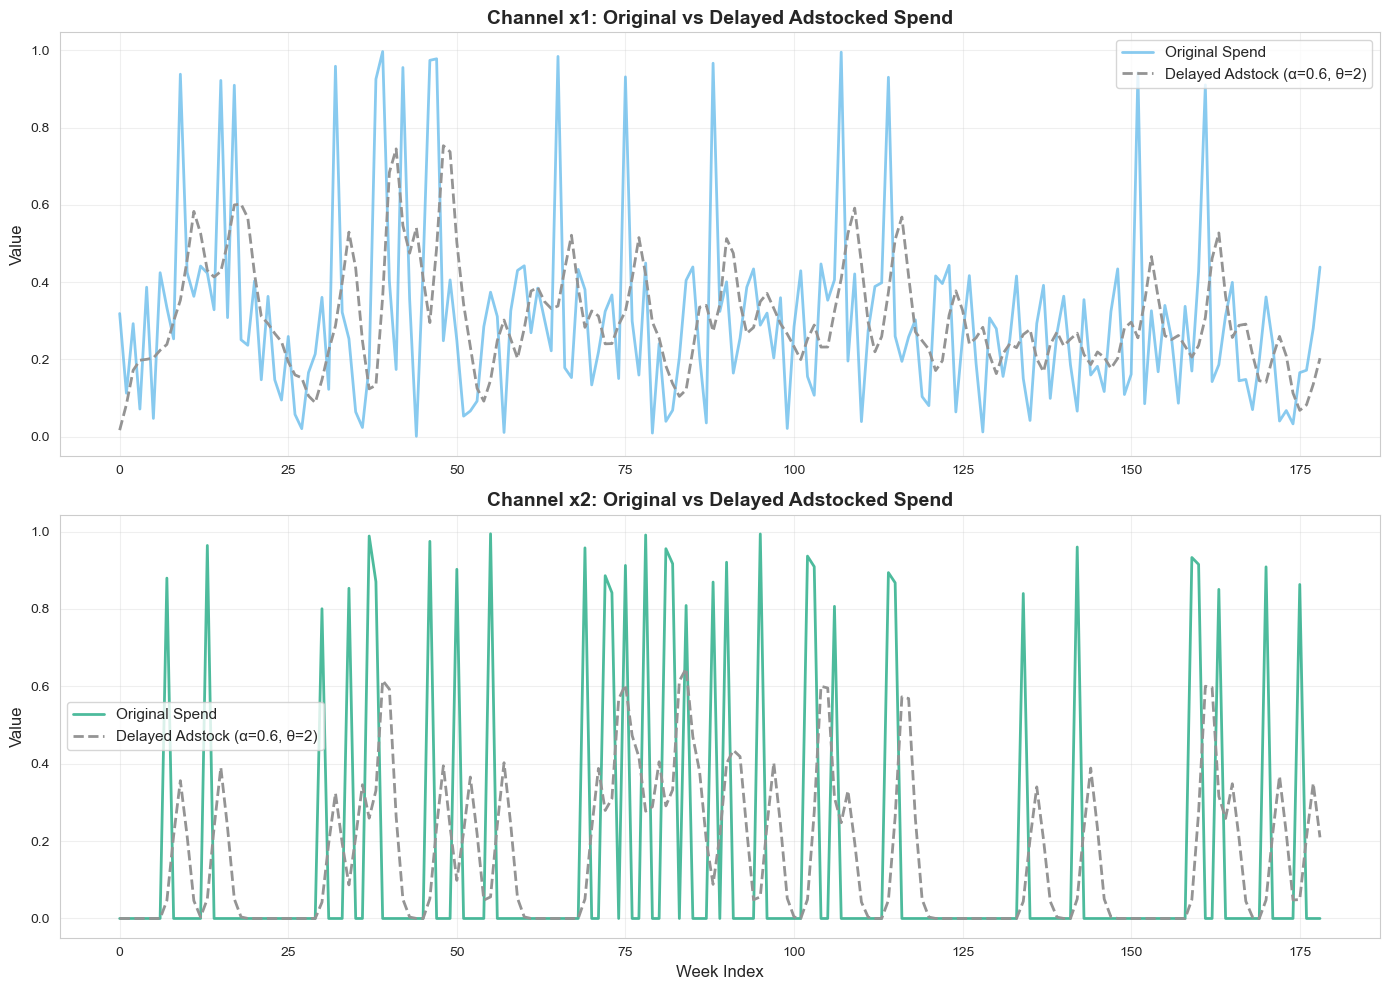

In [25]:
# Apply delayed adstock with moderate delay and decay
alpha = 0.6
theta = 2
x1_adstocked_delayed = delayed_adstock(
    ptx.as_xtensor(data["x1"].values, dims=("time",)),
    alpha=alpha,
    theta=theta,
    l_max=12,
    normalize=True,
    dim="time",
).eval()
x2_adstocked_delayed = delayed_adstock(
    ptx.as_xtensor(data["x2"].values, dims=("time",)),
    alpha=alpha,
    theta=theta,
    l_max=12,
    normalize=True,
    dim="time",
).eval()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Channel x1
ax1 = axes[0]
ax1.plot(
    data.index,
    data["x1"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH1,
)
ax1.plot(
    data.index,
    x1_adstocked_delayed,
    label=f"Delayed Adstock (α={alpha}, θ={theta})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax1.set_title(
    "Channel x1: Original vs Delayed Adstocked Spend", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Channel x2
ax2 = axes[1]
ax2.plot(
    data.index,
    data["x2"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH2,
)
ax2.plot(
    data.index,
    x2_adstocked_delayed,
    label=f"Delayed Adstock (α={alpha}, θ={theta})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax2.set_title(
    "Channel x2: Original vs Delayed Adstocked Spend", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Week Index", fontsize=12)
ax2.set_ylabel("Value", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

**Key Observations:**
- The delay creates a **lag** between spend and its full effect
- Notice how effects are **shifted forward in time** compared to geometric adstock
- Useful when you expect marketing to take time to "sink in"

---

## 3. Weibull CDF Adstock

### Overview
Weibull CDF adstock uses the **cumulative distribution function**, creating an **S-shaped curve** where effects build up gradually.

### Mathematical Form

The Weibull CDF is a function depending on two variables, $k$ (known as the **shape**) and $\lambda$ (known as the **scale**).  
The idea is closely related to geometric adstock but with one important difference : the rate of decay (what we called $\alpha$ in the geometric adstock equation) is no longer fixed. Instead it's **time-dependent**.

**The Weibull CDF adstock function therefore takes the form :**

$$x_t^{\textrm{transf}} = x_t + \alpha_t x_{t-1}^{\textrm{transf}}$$

- where $\alpha_t$ is now a function of time $t$

**The Weibull CDF is actually used to build the $\alpha_t$'s, and it takes the form :**

$$F_{k, \lambda}(t) = 1 - e^{-(\frac{t}{\lambda})^k}$$

Then, $\alpha_t$ is computed as :

$$\alpha_t = 1 - F_{k,\lambda}(t)$$

### When to Use
- **Brand building** campaigns with cumulative awareness
- **Long-term PR campaigns** where impact accumulates
- **Content marketing** that builds authority over time
- **Educational campaigns** with gradual learning
- When effects are **cumulative and slow-building**
- **Word-of-mouth marketing** that spreads gradually

### Parameters
- `lam`: Scale parameter (λ)
- `k`: Shape parameter
- `l_max`: Maximum lag periods

In [31]:
# Create Weibull CDF Adstock instance
weibull_cdf = WeibullCDFAdstock(l_max=12, normalize=True)

print("Weibull CDF Adstock Configuration:")
print(weibull_cdf)

Weibull CDF Adstock Configuration:
WeibullCDFAdstock(prefix='adstock', l_max=12, normalize=True, mode='After', priors={'lam': Prior("Gamma", mu=2, sigma=2.5), 'k': Prior("Gamma", mu=2, sigma=2.5)})


### Decay Curves for Different λ and k Values


Interpretation:
- CDF creates an S-shaped cumulative effect curve
- Effect builds up over time and plateaus
- λ controls the speed of buildup (lower λ = faster buildup)
- k controls the steepness of the S-curve


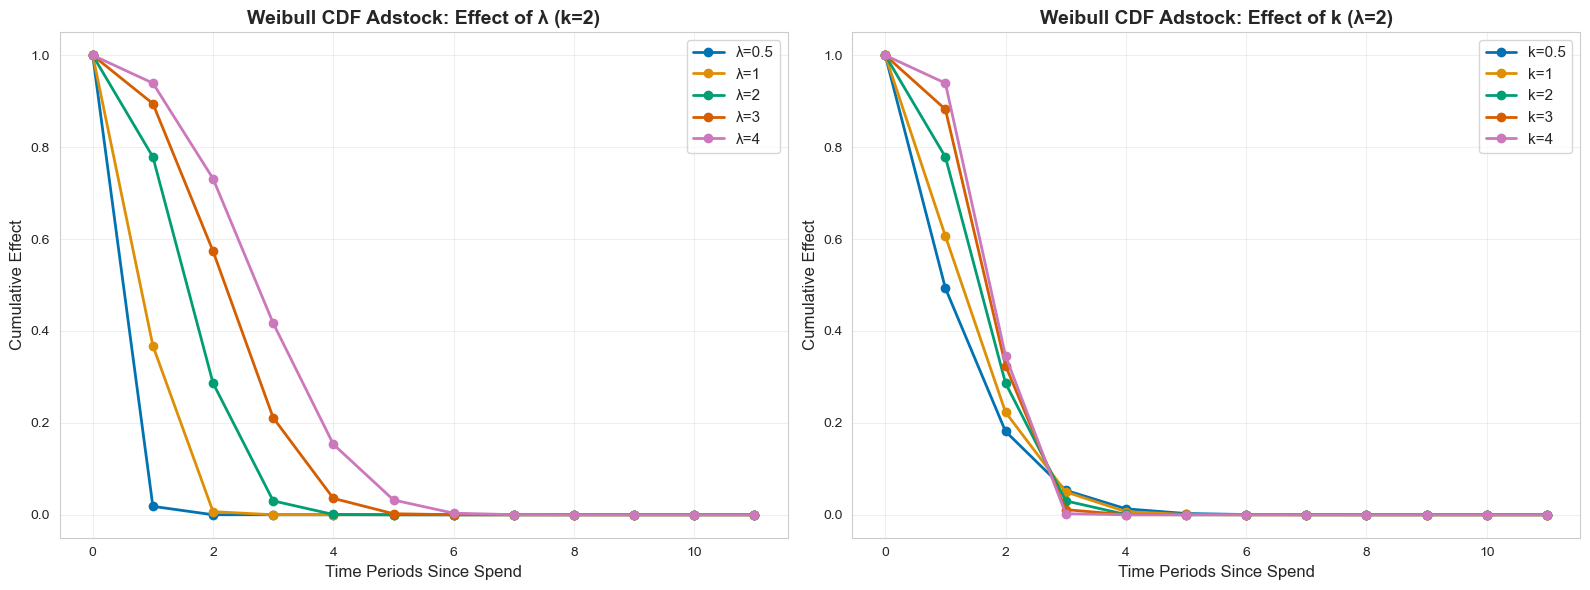

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

l_max = 12
impulse = np.zeros(l_max)
impulse[0] = 1.0

# Left plot: varying lambda (scale)
k = 2
lambdas = [0.5, 1, 2, 3, 4]

for lam in lambdas:
    result = weibull_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        lam=lam,
        k=k,
        l_max=l_max,
        type=WeibullType.CDF,
        normalize=False,
        dim="time",
    )
    axes[0].plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"λ={lam}")

axes[0].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[0].set_ylabel("Cumulative Effect", fontsize=12)
axes[0].set_title(
    f"Weibull CDF Adstock: Effect of λ (k={k})", fontsize=14, fontweight="bold"
)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right plot: varying k (shape)
lam = 2
ks = [0.5, 1, 2, 3, 4]

for k in ks:
    result = weibull_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        lam=lam,
        k=k,
        l_max=l_max,
        type=WeibullType.CDF,
        normalize=False,
        dim="time",
    )
    axes[1].plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"k={k}")

axes[1].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[1].set_ylabel("Cumulative Effect", fontsize=12)
axes[1].set_title(
    f"Weibull CDF Adstock: Effect of k (λ={lam})", fontsize=14, fontweight="bold"
)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

print("\nInterpretation:")
print("- CDF creates an S-shaped cumulative effect curve")
print("- Effect builds up over time and plateaus")
print("- λ controls the speed of buildup (lower λ = faster buildup)")
print("- k controls the steepness of the S-curve")

### Apply Weibull CDF Adstock to Channel Data

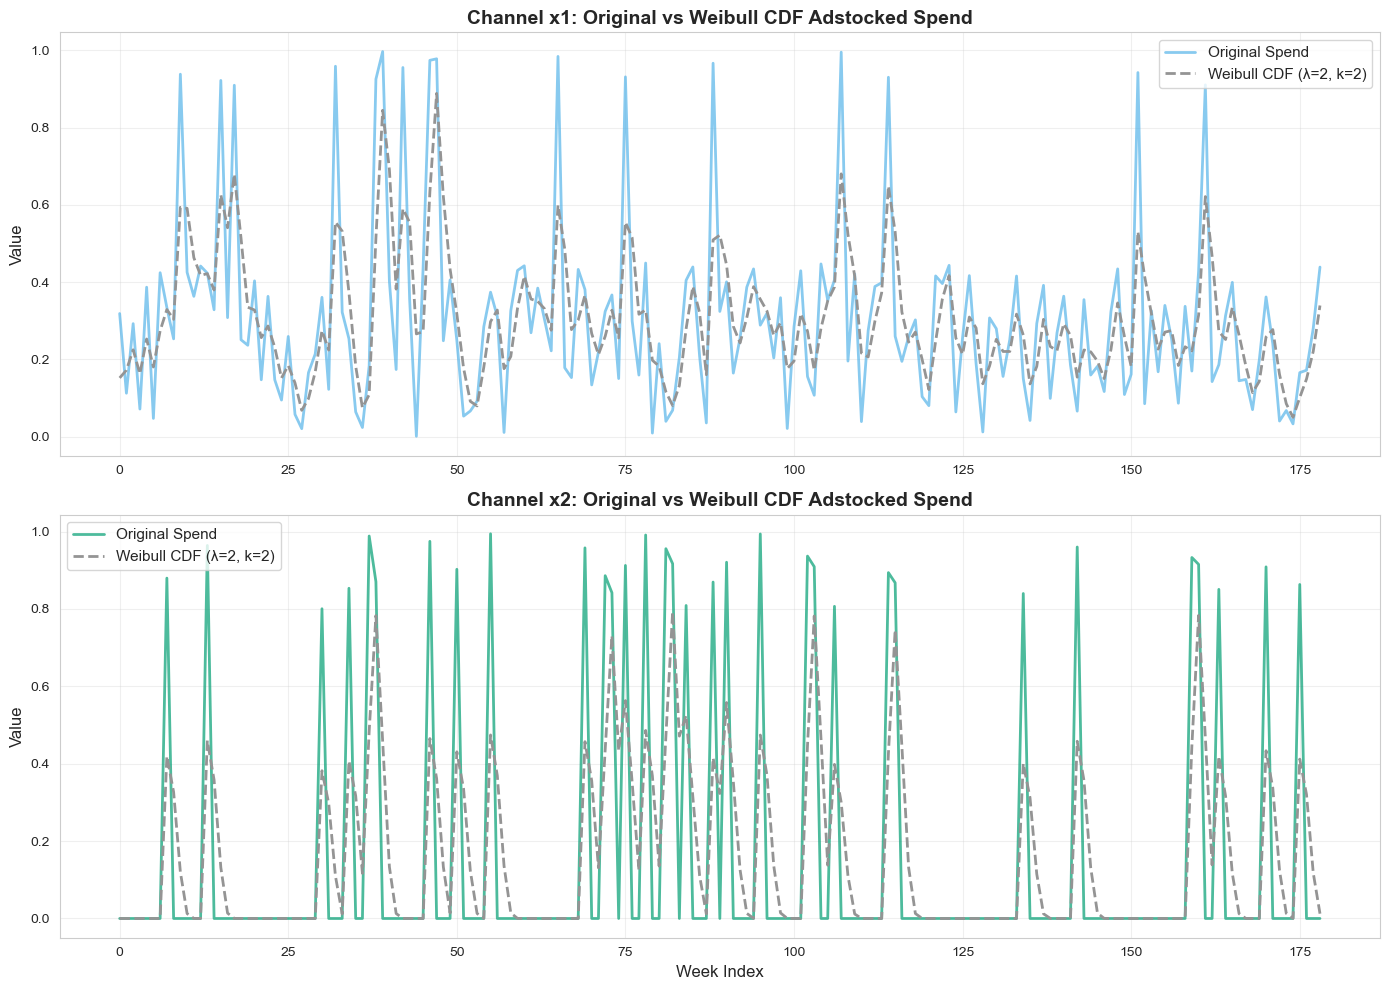

In [34]:
# Apply Weibull CDF adstock
lam = 2
k = 2
x1_adstocked_wcdf = weibull_adstock(
    ptx.as_xtensor(data["x1"].values, dims=("time",)),
    lam=lam,
    k=k,
    l_max=12,
    type=WeibullType.CDF,
    normalize=True,
    dim="time",
).eval()
x2_adstocked_wcdf = weibull_adstock(
    ptx.as_xtensor(data["x2"].values, dims=("time",)),
    lam=lam,
    k=k,
    l_max=12,
    type=WeibullType.CDF,
    normalize=True,
    dim="time",
).eval()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Channel x1
ax1 = axes[0]
ax1.plot(
    data.index,
    data["x1"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH1,
)
ax1.plot(
    data.index,
    x1_adstocked_wcdf,
    label=f"Weibull CDF (λ={lam}, k={k})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax1.set_title(
    "Channel x1: Original vs Weibull CDF Adstocked Spend",
    fontsize=14,
    fontweight="bold",
)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Channel x2
ax2 = axes[1]
ax2.plot(
    data.index,
    data["x2"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH2,
)
ax2.plot(
    data.index,
    x2_adstocked_wcdf,
    label=f"Weibull CDF (λ={lam}, k={k})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax2.set_title(
    "Channel x2: Original vs Weibull CDF Adstocked Spend",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Week Index", fontsize=12)
ax2.set_ylabel("Value", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

**Key Observations:**
- Weibull CDF shows **gradual buildup** of marketing effects
- Effects **accumulate** rather than immediately peak
- Particularly useful for long-term brand building

---

## 4. Weibull PDF Adstock

### Overview
Weibull PDF adstock uses the **probability density function** of the Weibull distribution, creating a **peak effect followed by decay**.

### Mathematical Form

The Weibull PDF is a function depending on two variables, $k$ (shape) and $\lambda$ (scale) and the same remarks for Weibull CDF apply to Weibull PDF.

The key difference is that Weibull PDF allows for lagged effects to be taken into account - the **time delay effect**. 

**The Weibull PDF adstock function therefore takes the form :**

$$
x_t^{\textrm{transf}} = x_t + \alpha_t x_{t-1}^{\textrm{transf}}
$$

- where $\alpha_t$ is now a function of time $t$

**The Weibull PDF is actually used to build the $\alpha_t$'s, and it takes the form :**

$$
G_{k,\lambda}(t) = \frac{k}{\lambda}\Big(\frac{t}{\lambda} \Big)^{k-1}e^{-(\frac{t}{\lambda})^k}
$$

### When to Use
- **Product launches** where interest peaks then declines
- **Promotional campaigns** with initial excitement that fades
- **Event-driven marketing** (sales, holidays)
- **Influencer marketing** where buzz builds then dissipates
- When you expect **maximum impact is not immediate** but occurs after some delay
- **Viral content** that peaks before declining

### Parameters
- `lam`: Scale parameter (λ) - controls peak timing
- `k`: Shape parameter - controls curve shape
- `l_max`: Maximum lag periods

In [27]:
# Create Weibull PDF Adstock instance
weibull_pdf = WeibullPDFAdstock(l_max=12, normalize=True)

print("Weibull PDF Adstock Configuration:")
print(weibull_pdf)

Weibull PDF Adstock Configuration:
WeibullPDFAdstock(prefix='adstock', l_max=12, normalize=True, mode='After', priors={'lam': Prior("Gamma", mu=2, sigma=1), 'k': Prior("Gamma", mu=3, sigma=1)})


### Decay Curves for Different λ and k Values


Interpretation:
- λ controls when the peak occurs (higher λ = later peak)
- k controls the shape (higher k = sharper peak, faster decay)


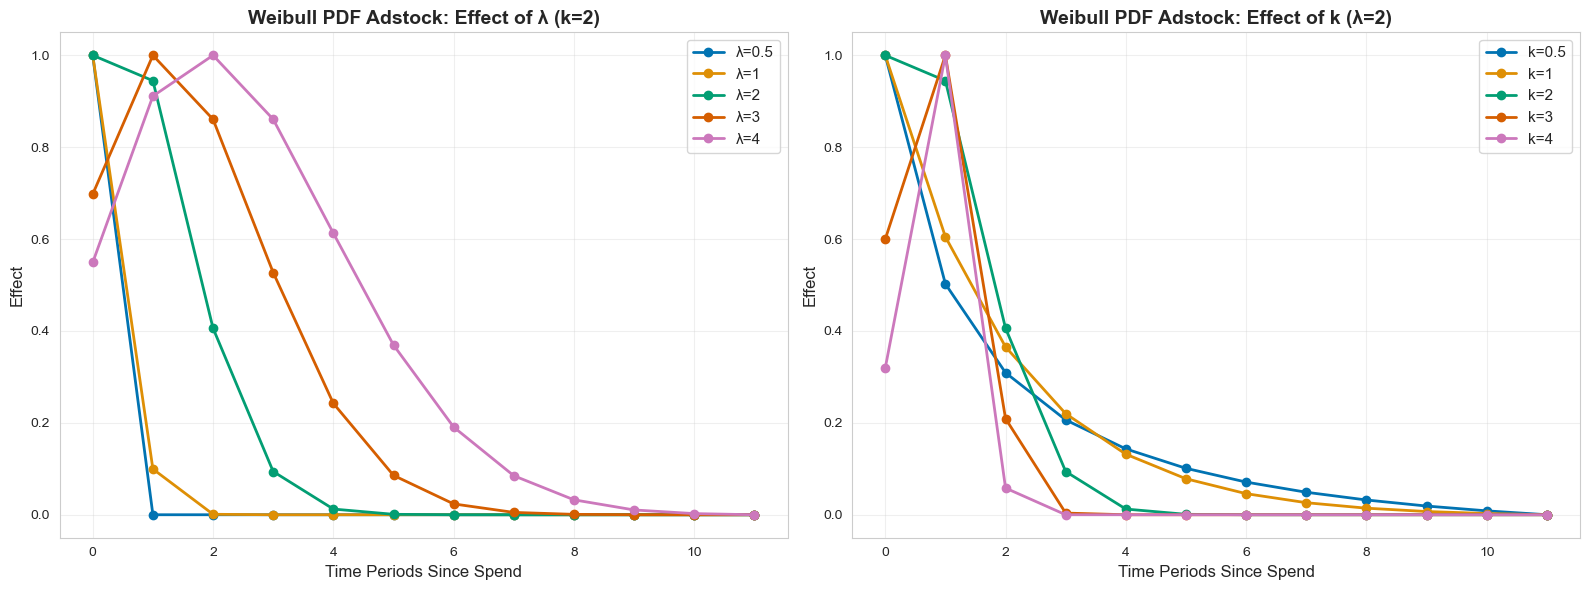

In [29]:
from pymc_marketing.mmm.transformers import WeibullType, weibull_adstock

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

l_max = 12
impulse = np.zeros(l_max)
impulse[0] = 1.0

# Left plot: varying lambda (scale)
k = 2
lambdas = [0.5, 1, 2, 3, 4]

for lam in lambdas:
    result = weibull_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        lam=lam,
        k=k,
        l_max=l_max,
        type=WeibullType.PDF,
        normalize=False,
        dim="time",
    )
    axes[0].plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"λ={lam}")

axes[0].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[0].set_ylabel("Effect", fontsize=12)
axes[0].set_title(
    f"Weibull PDF Adstock: Effect of λ (k={k})", fontsize=14, fontweight="bold"
)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right plot: varying k (shape)
lam = 2
ks = [0.5, 1, 2, 3, 4]

for k in ks:
    result = weibull_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        lam=lam,
        k=k,
        l_max=l_max,
        type=WeibullType.PDF,
        normalize=False,
        dim="time",
    )
    axes[1].plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"k={k}")

axes[1].set_xlabel("Time Periods Since Spend", fontsize=12)
axes[1].set_ylabel("Effect", fontsize=12)
axes[1].set_title(
    f"Weibull PDF Adstock: Effect of k (λ={lam})", fontsize=14, fontweight="bold"
)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

print("\nInterpretation:")
print("- λ controls when the peak occurs (higher λ = later peak)")
print("- k controls the shape (higher k = sharper peak, faster decay)")

### Apply Weibull PDF Adstock to Channel Data

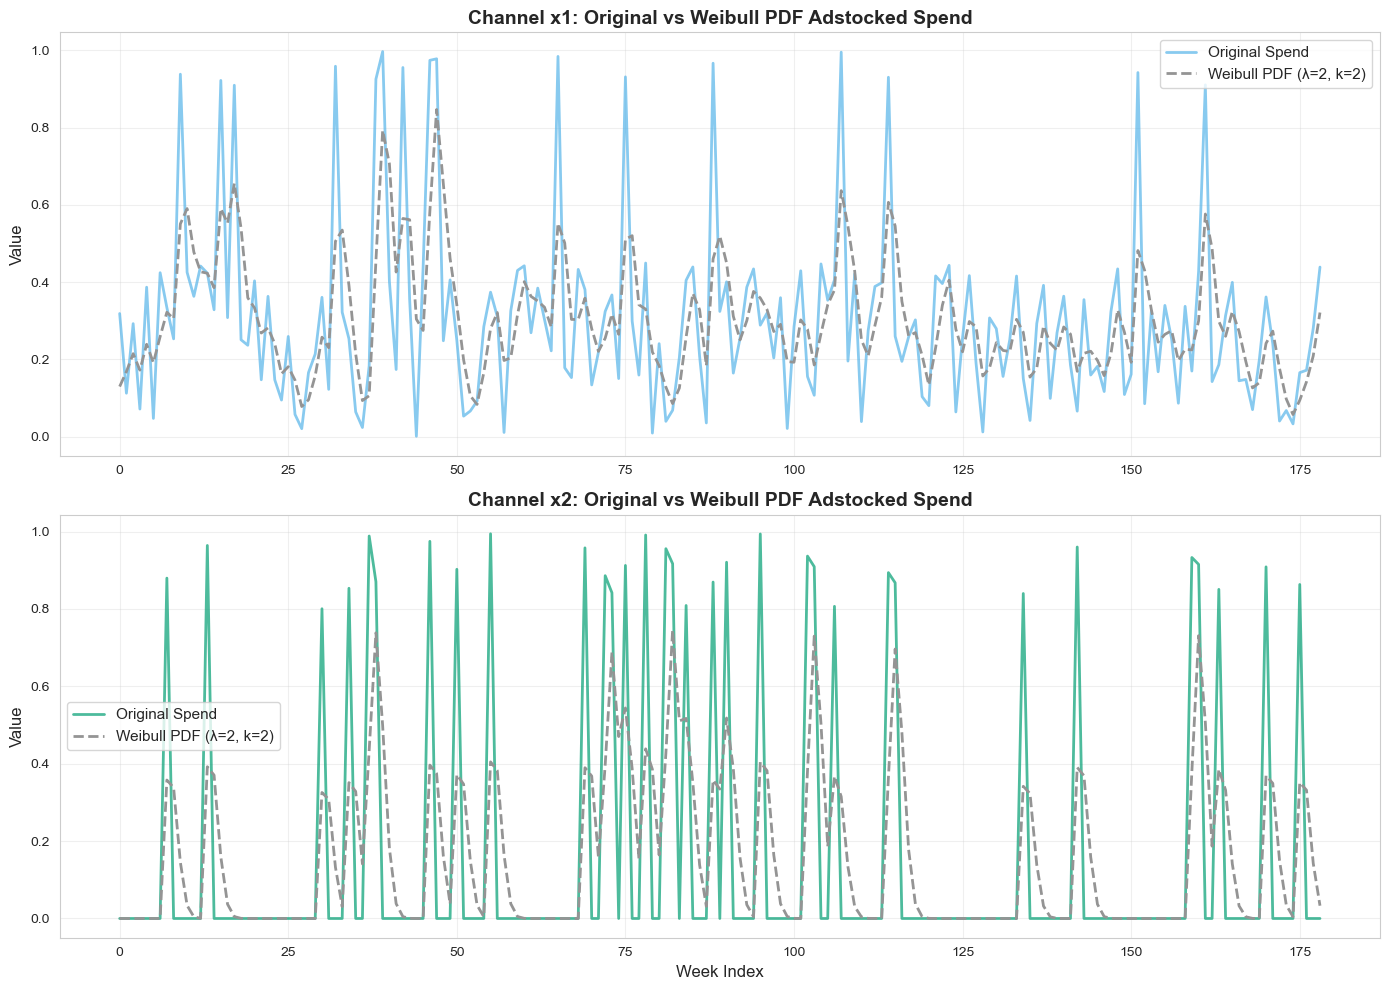

In [30]:
# Apply Weibull PDF adstock
lam = 2
k = 2
x1_adstocked_wpdf = weibull_adstock(
    ptx.as_xtensor(data["x1"].values, dims=("time",)),
    lam=lam,
    k=k,
    l_max=12,
    type=WeibullType.PDF,
    normalize=True,
    dim="time",
).eval()
x2_adstocked_wpdf = weibull_adstock(
    ptx.as_xtensor(data["x2"].values, dims=("time",)),
    lam=lam,
    k=k,
    l_max=12,
    type=WeibullType.PDF,
    normalize=True,
    dim="time",
).eval()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Channel x1
ax1 = axes[0]
ax1.plot(
    data.index,
    data["x1"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH1,
)
ax1.plot(
    data.index,
    x1_adstocked_wpdf,
    label=f"Weibull PDF (λ={lam}, k={k})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax1.set_title(
    "Channel x1: Original vs Weibull PDF Adstocked Spend",
    fontsize=14,
    fontweight="bold",
)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Channel x2
ax2 = axes[1]
ax2.plot(
    data.index,
    data["x2"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH2,
)
ax2.plot(
    data.index,
    x2_adstocked_wpdf,
    label=f"Weibull PDF (λ={lam}, k={k})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax2.set_title(
    "Channel x2: Original vs Weibull PDF Adstocked Spend",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Week Index", fontsize=12)
ax2.set_ylabel("Value", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

**Key Observations:**
- The Weibull PDF creates a **peak effect** after the spend
- Useful for modeling campaigns where impact **builds before declining**
- Different from geometric where effect is immediate

---

## 5. Binomial Adstock

### Overview
Binomial adstock provides a **flexible decay curve** based on the binomial distribution.

### Mathematical Form

Binomial adstock assumes that the effect of one unit of spend at time $t$ is given by:

$$f(t) = \left(1 - \frac{t}{L + 1} \right)^{\left(\frac{1}{\alpha} - 1\right)}$$

Where:
- $t$ is the time since the advertising spend ($0 \le t \le L + 1$)
- $L$ is `l_max`, the maximum duration of carryover effect
- $\alpha \in (0, 1)$ is the shape parameter controlling the decay curve
- Notice that $f(L + 1) = 0$

The binomial adstock transformation provides more flexible decay shapes compared to geometric adstock. The $\alpha$ parameter controls both the shape and the decay rate, allowing for convex and concave decay patterns.

### When to Use
- When you need **more flexible decay shapes** than geometric
- **Social media advertising** with variable decay patterns
- **Email marketing** where engagement varies over time
- When geometric adstock is **too restrictive**
- When you want decay to be **data-driven** rather than assumed

### Parameters
- `alpha`: Shape parameter controlling decay curve
- `l_max`: Maximum lag periods

In [35]:
# Create Binomial Adstock instance
binomial = BinomialAdstock(l_max=12, normalize=True)

print("Binomial Adstock Configuration:")
print(binomial)

Binomial Adstock Configuration:
BinomialAdstock(prefix='adstock', l_max=12, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3)})


### Decay Curves for Different Alpha Values


Interpretation:
- Binomial adstock offers more flexible decay shapes
- α controls the decay pattern, allowing for convex/concave curves


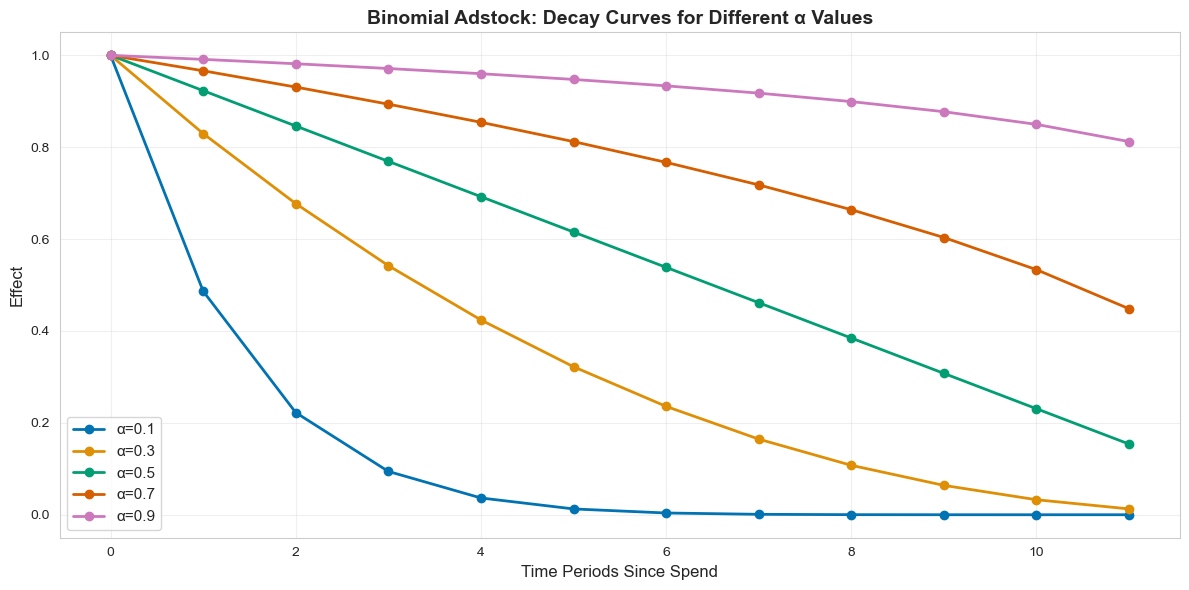

In [37]:
from pymc_marketing.mmm.transformers import binomial_adstock

fig, ax = plt.subplots(figsize=(12, 6))

alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
l_max = 12

impulse = np.zeros(l_max)
impulse[0] = 1.0

for alpha in alphas:
    result = binomial_adstock(
        ptx.as_xtensor(impulse, dims=("time",)),
        alpha=alpha,
        l_max=l_max,
        normalize=False,
        dim="time",
    )
    ax.plot(range(l_max), result.eval(), marker="o", linewidth=2, label=f"α={alpha}")

ax.set_xlabel("Time Periods Since Spend", fontsize=12)
ax.set_ylabel("Effect", fontsize=12)
ax.set_title(
    "Binomial Adstock: Decay Curves for Different α Values",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

print("\nInterpretation:")
print("- Binomial adstock offers more flexible decay shapes")
print("- α controls the decay pattern, allowing for convex/concave curves")

### Apply Binomial Adstock to Channel Data

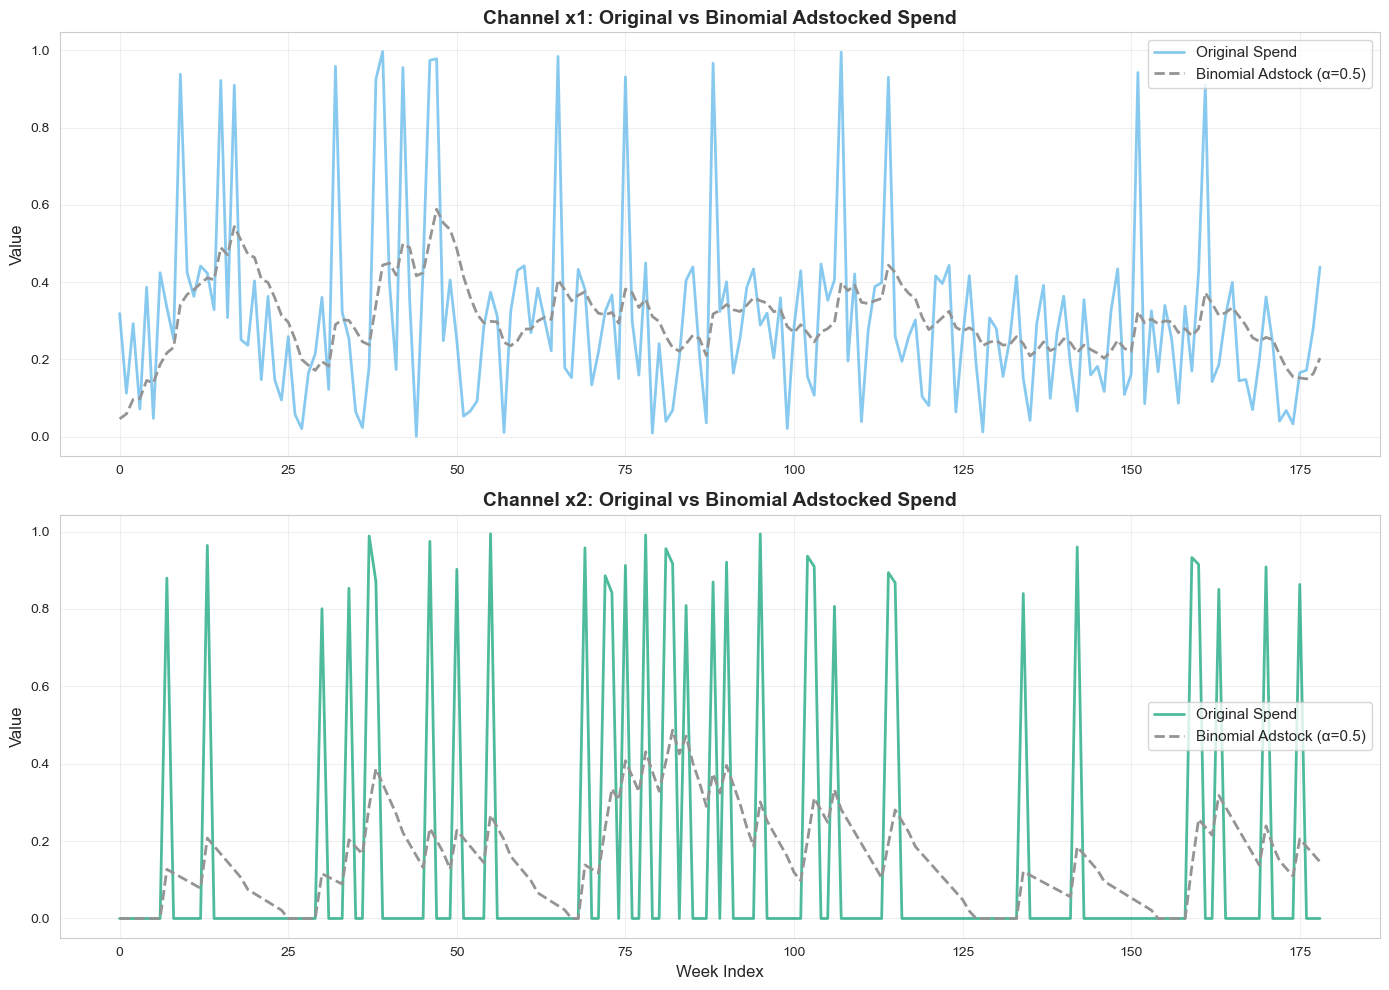

In [39]:
# Apply binomial adstock
alpha = 0.5
x1_adstocked_binom = binomial_adstock(
    ptx.as_xtensor(data["x1"].values, dims=("time",)),
    alpha=alpha,
    l_max=12,
    normalize=True,
    dim="time",
).eval()
x2_adstocked_binom = binomial_adstock(
    ptx.as_xtensor(data["x2"].values, dims=("time",)),
    alpha=alpha,
    l_max=12,
    normalize=True,
    dim="time",
).eval()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Channel x1
ax1 = axes[0]
ax1.plot(
    data.index,
    data["x1"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH1,
)
ax1.plot(
    data.index,
    x1_adstocked_binom,
    label=f"Binomial Adstock (α={alpha})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax1.set_title(
    "Channel x1: Original vs Binomial Adstocked Spend", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Channel x2
ax2 = axes[1]
ax2.plot(
    data.index,
    data["x2"],
    label="Original Spend",
    linewidth=2,
    alpha=0.7,
    color=COLOR_CH2,
)
ax2.plot(
    data.index,
    x2_adstocked_binom,
    label=f"Binomial Adstock (α={alpha})",
    linewidth=2,
    linestyle="--",
    color=CB_COLORS[7],
)
ax2.set_title(
    "Channel x2: Original vs Binomial Adstocked Spend", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Week Index", fontsize=12)
ax2.set_ylabel("Value", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

---

## 6. Comparison Across All Adstock Functions

Let's compare all adstock functions side-by-side to understand their differences:

### Decay Curve Comparison


Key Differences:
- Geometric (blue): Immediate peak, exponential decay
- Delayed (orange): Peak shifted forward in time
- Weibull CDF (purple): Gradual S-shaped buildup
- Weibull PDF (red): Peak after delay, then decay
- Binomial (green): Flexible decay shape


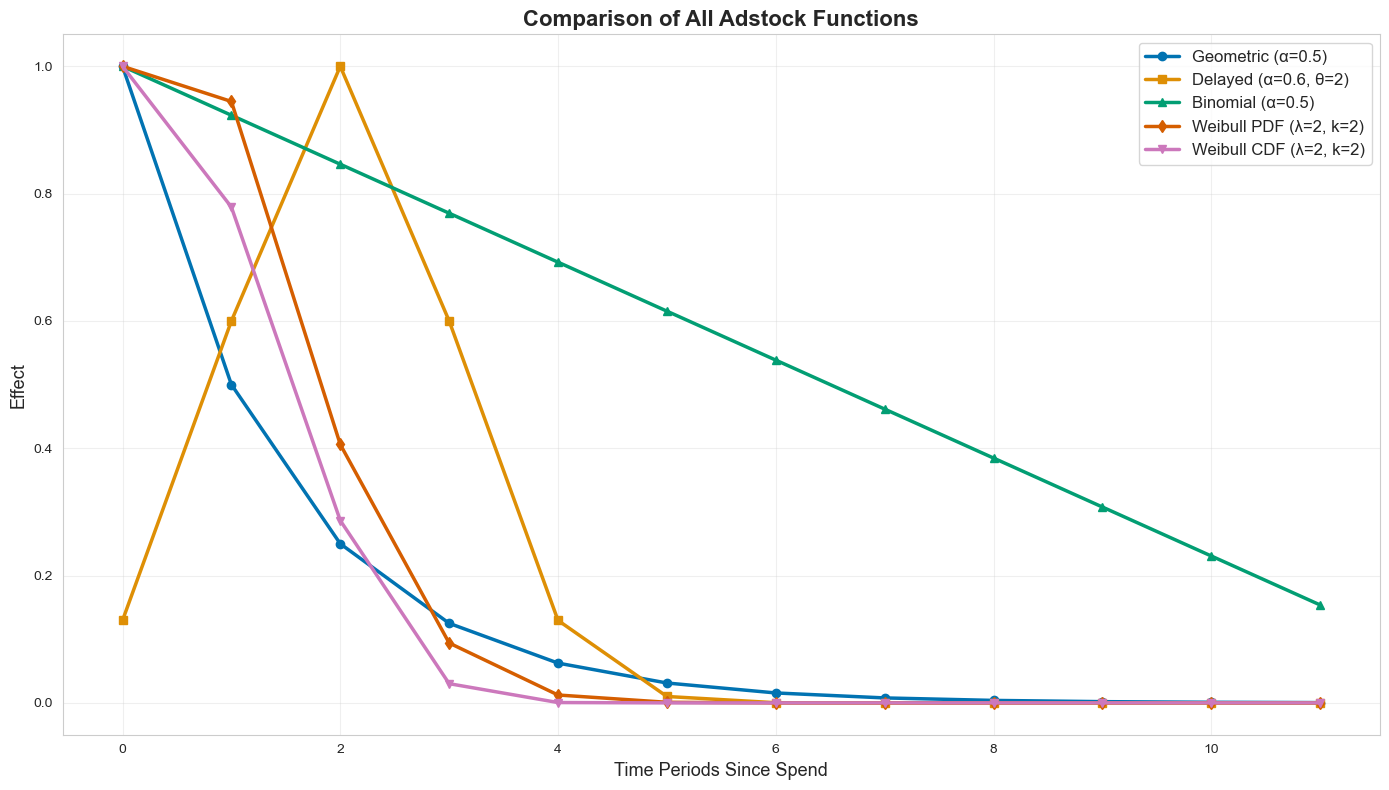

In [43]:
fig, ax = plt.subplots(figsize=(14, 8))

l_max = 12
impulse = np.zeros(l_max)
impulse[0] = 1.0

# Geometric
geo = geometric_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.5,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    geo,
    marker="o",
    linewidth=2.5,
    label="Geometric (α=0.5)",
    markersize=6,
    color=CB_COLORS[0],
)

# Delayed
delayed_result = delayed_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.6,
    theta=2,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    delayed_result,
    marker="s",
    linewidth=2.5,
    label="Delayed (α=0.6, θ=2)",
    markersize=6,
    color=CB_COLORS[1],
)

# Binomial
binom = binomial_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.5,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    binom,
    marker="^",
    linewidth=2.5,
    label="Binomial (α=0.5)",
    markersize=6,
    color=CB_COLORS[2],
)

# Weibull PDF
wpdf = weibull_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    lam=2,
    k=2,
    l_max=l_max,
    type=WeibullType.PDF,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    wpdf,
    marker="d",
    linewidth=2.5,
    label="Weibull PDF (λ=2, k=2)",
    markersize=6,
    color=CB_COLORS[3],
)

# Weibull CDF
wcdf = weibull_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    lam=2,
    k=2,
    l_max=l_max,
    type=WeibullType.CDF,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    wcdf,
    marker="v",
    linewidth=2.5,
    label="Weibull CDF (λ=2, k=2)",
    markersize=6,
    color=CB_COLORS[4],
)

ax.set_xlabel("Time Periods Since Spend", fontsize=13)
ax.set_ylabel("Effect", fontsize=13)
ax.set_title("Comparison of All Adstock Functions", fontsize=16, fontweight="bold")
ax.legend(fontsize=12, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print("\nKey Differences:")
print("- Geometric (blue): Immediate peak, exponential decay")
print("- Delayed (orange): Peak shifted forward in time")
print("- Weibull CDF (purple): Gradual S-shaped buildup")
print("- Weibull PDF (red): Peak after delay, then decay")
print("- Binomial (green): Flexible decay shape")

---

## Summary: Which Adstock Function Should You Use?

### Decision Guide

| **Adstock Type** | **Best For** | **Key Characteristics** |
|-----------------|--------------|------------------------|
| **Geometric** | Digital ads, search, display, most use cases | Simple exponential decay, immediate effect |
| **Delayed** | TV, radio, OOH, B2B marketing | Delayed peak with exponential decay |
| **Binomial** | Social media, email, flexible modeling | Versatile decay shapes, data-driven |
| **Weibull PDF** | Product launches, promotions, events | Peak effect after delay, then decay |
| **Weibull CDF** | Brand building, PR, content marketing | Gradual S-shaped buildup, cumulative effects |

### General Recommendations

1. **Start with Geometric**: It's the most widely used and works well for most channels
2. **Use Delayed for Traditional Media**: TV and radio often have delayed effects
3. **Try Weibull PDF for Campaigns**: Product launches and promotions benefit from peak modeling
4. **Consider Weibull CDF for Brand Building**: Long-term effects accumulate gradually
5. **Let the Data Decide**: Compare model fit across different adstock functions

### Model Selection Tips

- **Run multiple models** with different adstock functions
- **Check posterior predictive** plots for each adstock type
- **Consider business knowledge** about your marketing channels
- **Test sensitivity** to different parameter priors

Remember: The "best" adstock function depends on your specific marketing channels, business context, and data!

Happy modeling! 🚀